#  Exploratory Data Analysis (EDA)
## Olist E-commerce Sales & Customer Analytics

Notebook này khám phá thống kê và trực quan hóa dữ liệu đã xử lý (`data/processed/`)
để hiểu xu hướng, phát hiện bất thường, và hỗ trợ các insight kinh doanh ở Phase 12.

**Nội dung:**
1. Load dữ liệu đã xử lý
2. Thống kê mô tả tổng quan
3. Histogram: phân phối Revenue, Delivery Days, Review Score
4. Boxplot: Giá theo Category, Delivery Days theo Review Score
5. Correlation Matrix
6. Line chart: Xu hướng doanh thu theo tháng
7. Bar chart: Top Category, Revenue theo Bang
8. Scatter plot: Delivery Days vs Review Score
9. Tổng kết insight


## 1. Import thư viện & Load dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

PROC = "../data/processed/"

orders = pd.read_csv(PROC + "orders_processed.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date"
])
order_items = pd.read_csv(PROC + "order_items_processed.csv")
products = pd.read_csv(PROC + "products_processed.csv")
customers = pd.read_csv(PROC + "customers_processed.csv")

delivered = orders[orders["order_status"] == "delivered"].copy()
print(f"Tổng số đơn: {len(orders):,} | Đơn delivered: {len(delivered):,}")


Tổng số đơn: 99,441 | Đơn delivered: 96,478


## 2. Thống kê mô tả tổng quan

In [2]:
delivered[["order_revenue", "freight_total", "delivery_days", "items_count", "review_score"]].describe()


,order_revenue,freight_total,delivery_days,items_count,review_score
count,96478.000000,96478.000000,96470.000000,96478.000000,95372.000000
mean,159.826839,22.785253,12.093604,1.142198,4.158118
std,218.794219,21.559197,9.551380,0.538804,1.282374
min,9.590000,0.000000,0.000000,1.000000,1.000000
25%,61.850000,13.850000,6.000000,1.000000,4.000000
50%,105.280000,17.170000,10.000000,1.000000,5.000000
75%,176.260000,24.017500,15.000000,1.000000,5.000000
max,13664.080000,1794.960000,209.000000,21.000000,5.000000


In [3]:
avg_revenue = delivered["order_revenue"].mean()
median_revenue = delivered["order_revenue"].median()
avg_delivery = delivered["delivery_days"].mean()

print(f"Order Revenue - Mean: R$ {avg_revenue:.2f} | Median: R$ {median_revenue:.2f}")
print(f"Delivery Days - Mean: {avg_delivery:.1f} ngày")
print("\n-> Mean > Median rõ rệt cho thấy phân phối revenue lệch phải (right-skewed):")
print("   đa số đơn có giá trị nhỏ, số ít đơn giá trị rất lớn kéo mean lên cao.")


Order Revenue - Mean: R$ 159.83 | Median: R$ 105.28
Delivery Days - Mean: 12.1 ngày

-> Mean > Median rõ rệt cho thấy phân phối revenue lệch phải (right-skewed):
   đa số đơn có giá trị nhỏ, số ít đơn giá trị rất lớn kéo mean lên cao.


## 3. Histogram — Phân phối các biến chính

### 3.1 Phân phối Doanh thu theo Đơn hàng

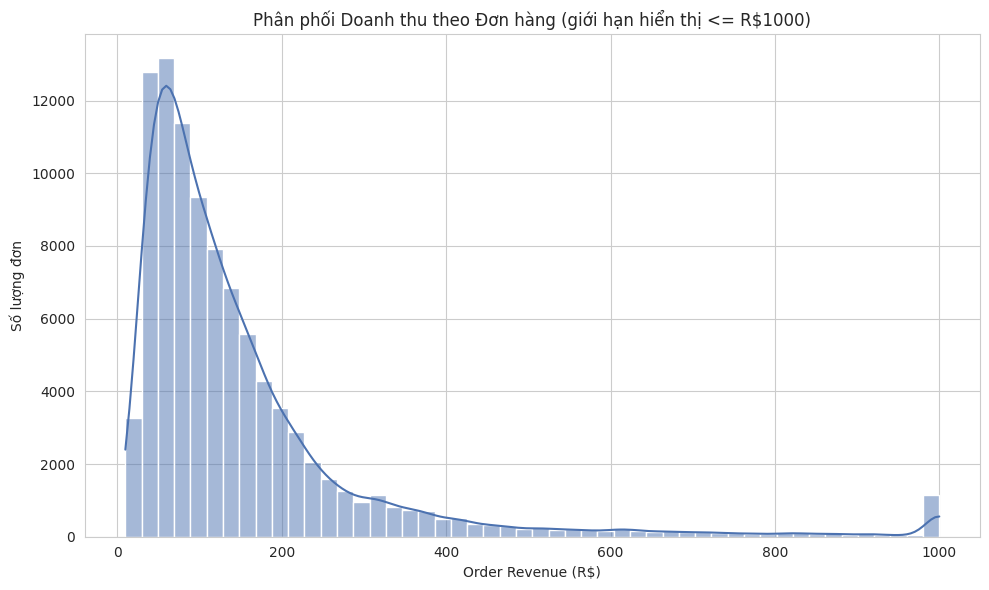

In [4]:
plt.figure()
sns.histplot(delivered["order_revenue"].clip(upper=1000), bins=50, kde=True, color="#4C72B0")
plt.title("Phân phối Doanh thu theo Đơn hàng (giới hạn hiển thị <= R$1000)")
plt.xlabel("Order Revenue (R$)")
plt.ylabel("Số lượng đơn")
plt.tight_layout()
plt.show()


### 3.2 Phân phối Thời gian Giao hàng

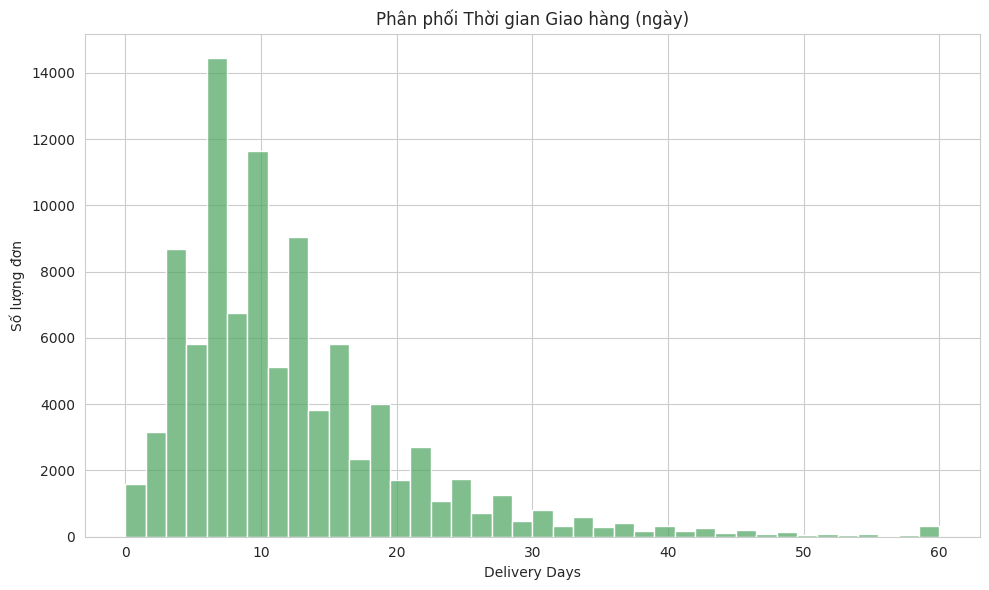

In [5]:
plt.figure()
sns.histplot(delivered["delivery_days"].dropna().clip(upper=60), bins=40, color="#55A868")
plt.title("Phân phối Thời gian Giao hàng (ngày)")
plt.xlabel("Delivery Days")
plt.ylabel("Số lượng đơn")
plt.tight_layout()
plt.show()


### 3.3 Phân phối Điểm Đánh giá

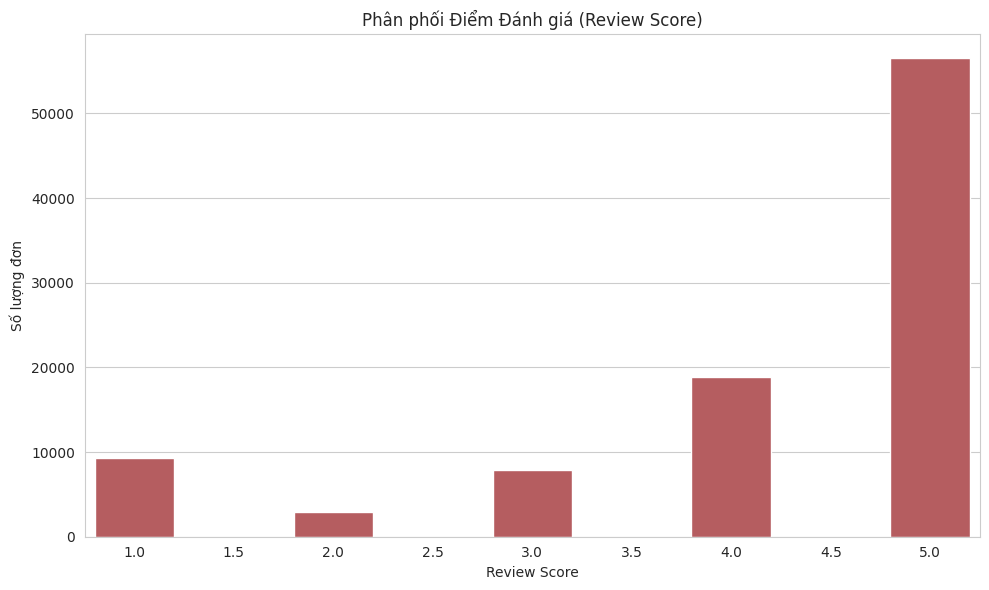

In [6]:
plt.figure()
sns.countplot(x="review_score", data=delivered.dropna(subset=["review_score"]), color="#C44E52")
plt.title("Phân phối Điểm Đánh giá (Review Score)")
plt.xlabel("Review Score")
plt.ylabel("Số lượng đơn")
plt.tight_layout()
plt.show()


## 4. Boxplot — Phát hiện Outlier & So sánh nhóm

### 4.1 Giá sản phẩm theo Top 10 Category

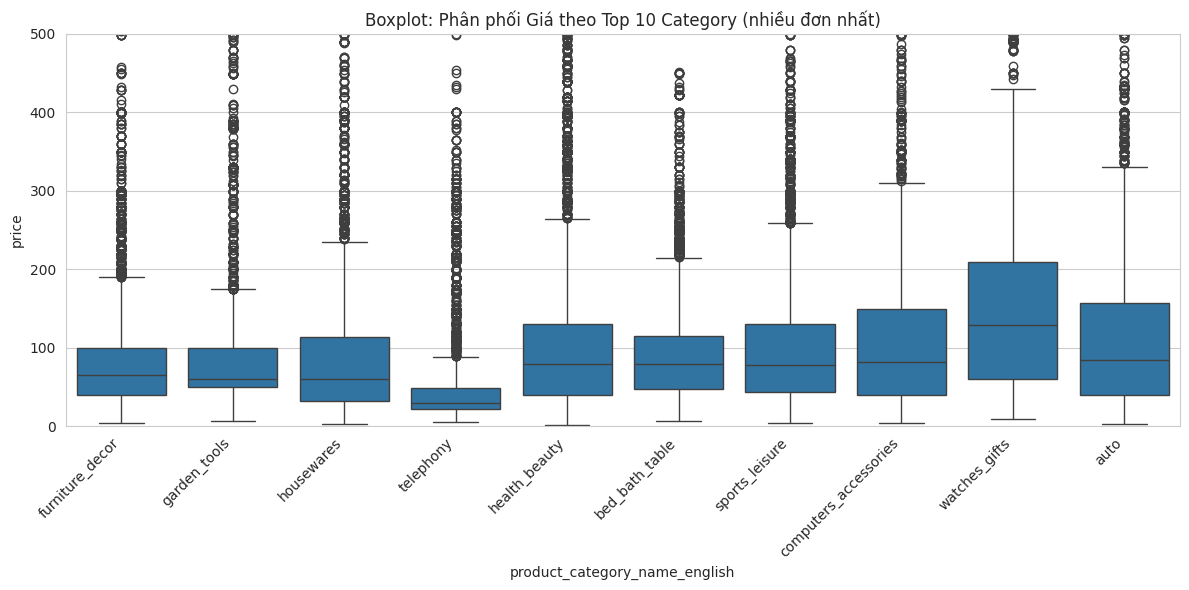

In [7]:
merged = order_items.merge(products[["product_id", "product_category_name_english"]], on="product_id")
top10_cat = merged["product_category_name_english"].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=merged[merged["product_category_name_english"].isin(top10_cat)],
    x="product_category_name_english", y="price"
)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot: Phân phối Giá theo Top 10 Category (nhiều đơn nhất)")
plt.ylim(0, 500)
plt.tight_layout()
plt.show()


### 4.2 Thời gian Giao hàng theo Điểm Đánh giá

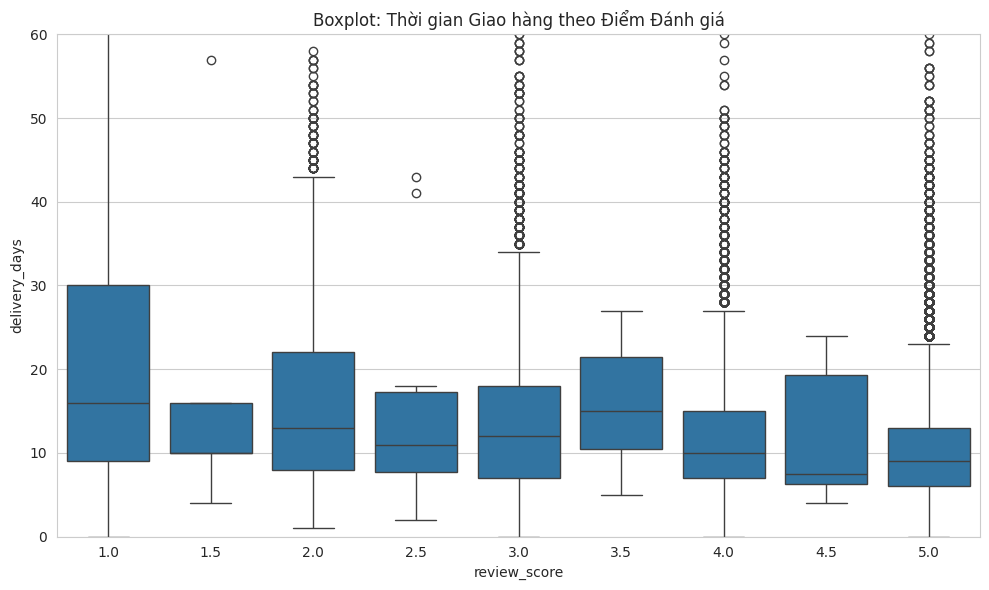

In [8]:
plt.figure()
sns.boxplot(
    data=delivered.dropna(subset=["review_score", "delivery_days"]),
    x="review_score", y="delivery_days"
)
plt.ylim(0, 60)
plt.title("Boxplot: Thời gian Giao hàng theo Điểm Đánh giá")
plt.tight_layout()
plt.show()


## 5. Correlation Matrix

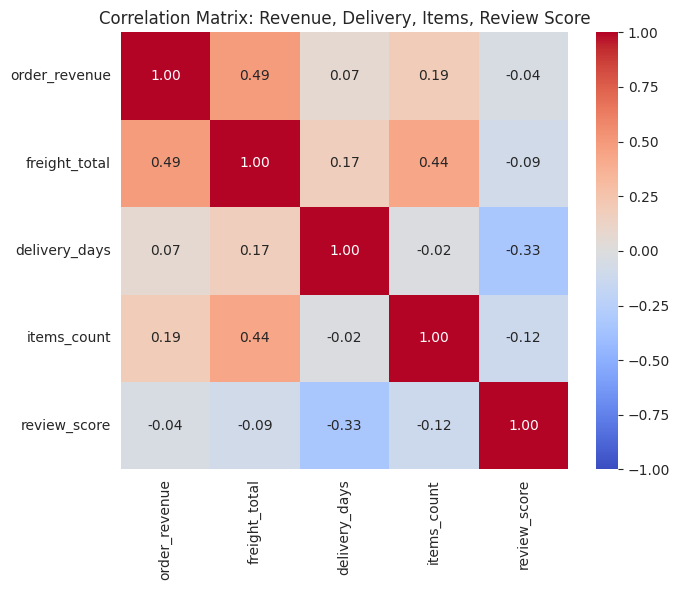

Correlation(delivery_days, review_score) = -0.334


In [9]:
numeric_cols = delivered[["order_revenue", "freight_total", "delivery_days",
                           "items_count", "review_score"]].dropna()
corr = numeric_cols.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: Revenue, Delivery, Items, Review Score")
plt.tight_layout()
plt.show()

corr_delivery_review = corr.loc["delivery_days", "review_score"]
print(f"Correlation(delivery_days, review_score) = {corr_delivery_review:.3f}")


**Nhận xét:** Tương quan âm giữa `delivery_days` và `review_score` cho thấy
giao hàng càng lâu thì điểm đánh giá có xu hướng càng thấp — đây là driver quan trọng
nhất cần theo dõi ở Operations Dashboard (Phase 11).

## 6. Xu hướng Doanh thu theo Tháng

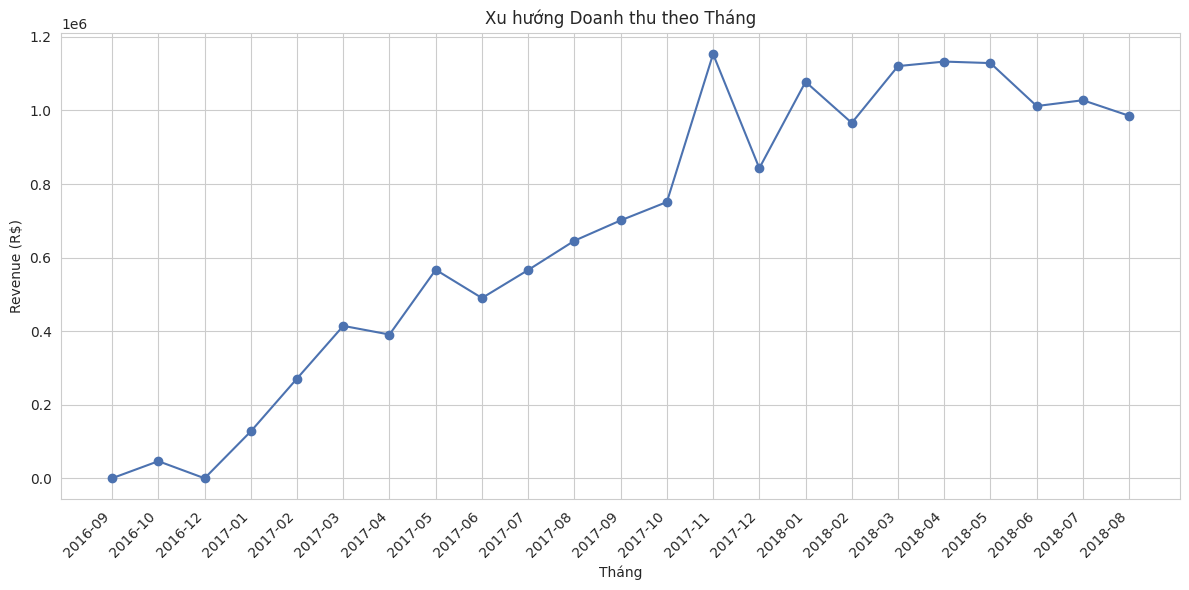

In [10]:
monthly = delivered.groupby("order_month")["order_revenue"].sum().reset_index()
monthly = monthly.sort_values("order_month")

plt.figure(figsize=(12, 6))
plt.plot(monthly["order_month"], monthly["order_revenue"], marker="o", color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.title("Xu hướng Doanh thu theo Tháng")
plt.xlabel("Tháng")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()


## 7. Bar Chart — Doanh thu theo Category & Bang

### 7.1 Top 10 Category theo Doanh thu

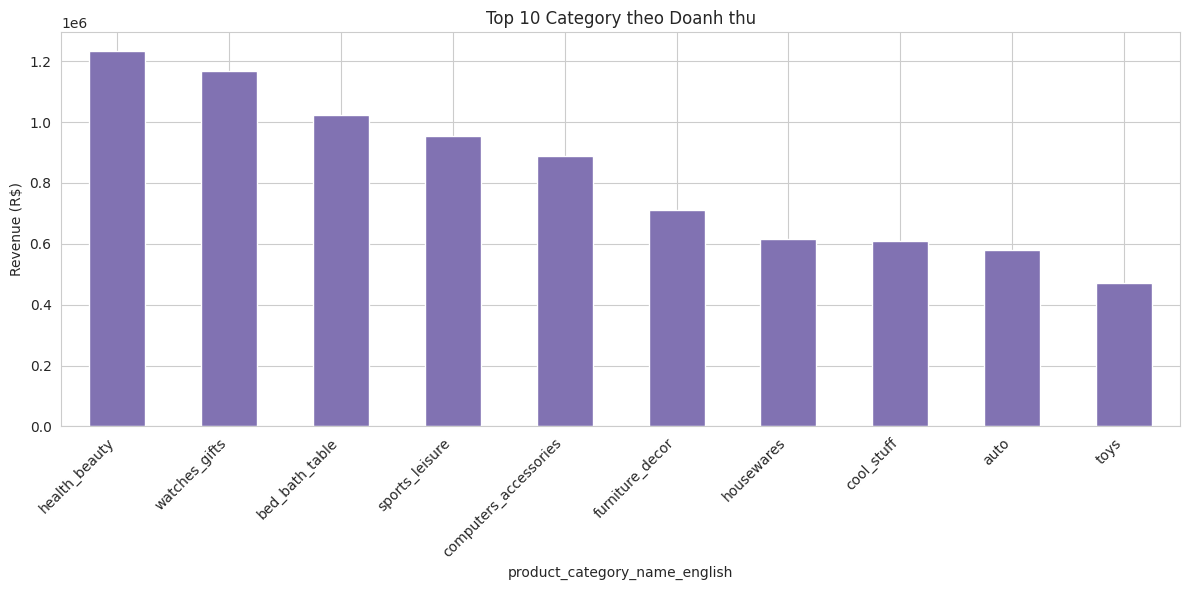

In [11]:
cat_revenue = order_items.merge(products[["product_id", "product_category_name_english"]], on="product_id")
cat_revenue = cat_revenue[cat_revenue["order_id"].isin(delivered["order_id"])]
cat_revenue = cat_revenue.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
cat_revenue.plot(kind="bar", color="#8172B2")
plt.title("Top 10 Category theo Doanh thu")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 7.2 Doanh thu theo Bang (State)

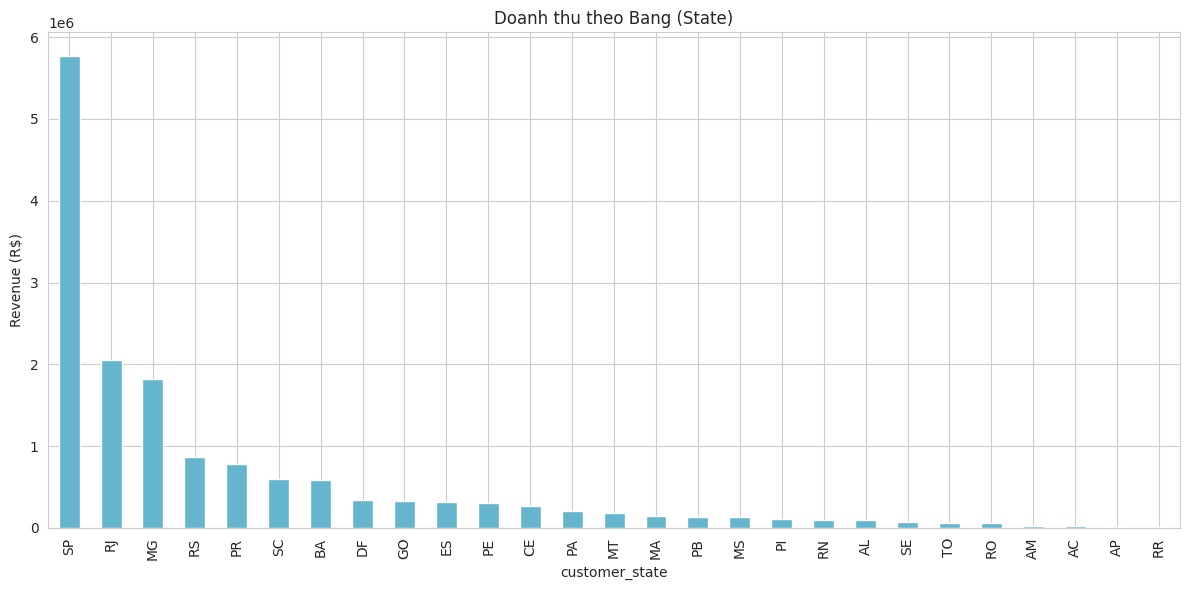

In [12]:
state_revenue = delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id") \
    .groupby("customer_state")["order_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_revenue.plot(kind="bar", color="#64B5CD")
plt.title("Doanh thu theo Bang (State)")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()


## 8. Scatter Plot — Delivery Days vs Review Score

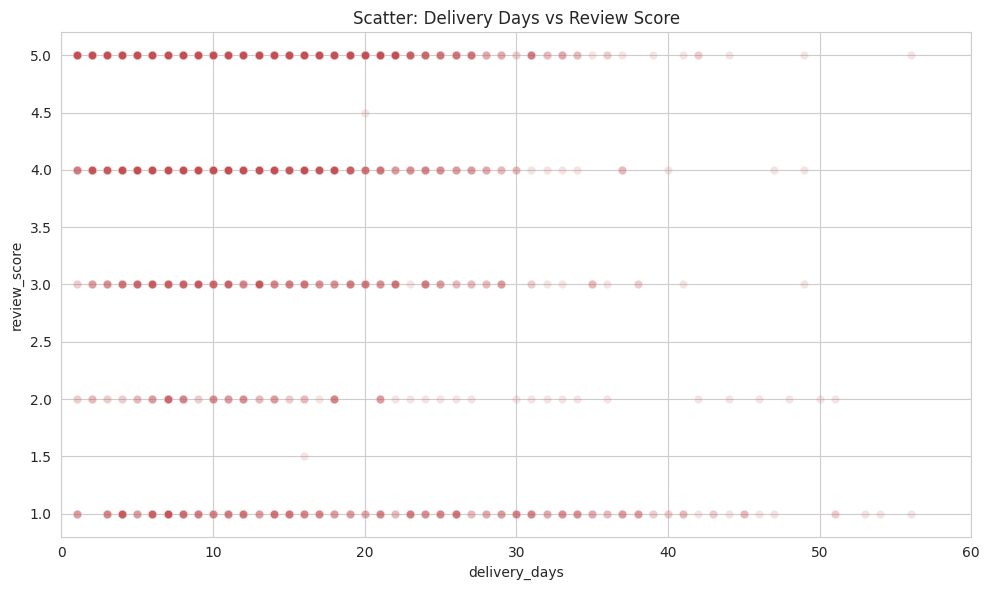

In [13]:
sample_df = delivered.dropna(subset=["delivery_days", "review_score"])
sample = sample_df.sample(min(3000, len(sample_df)), random_state=42)

plt.figure()
sns.scatterplot(data=sample, x="delivery_days", y="review_score", alpha=0.15, color="#C44E52")
plt.xlim(0, 60)
plt.title("Scatter: Delivery Days vs Review Score")
plt.tight_layout()
plt.show()
